-> Đang vẽ: Walking (Mẫu index: 1096)


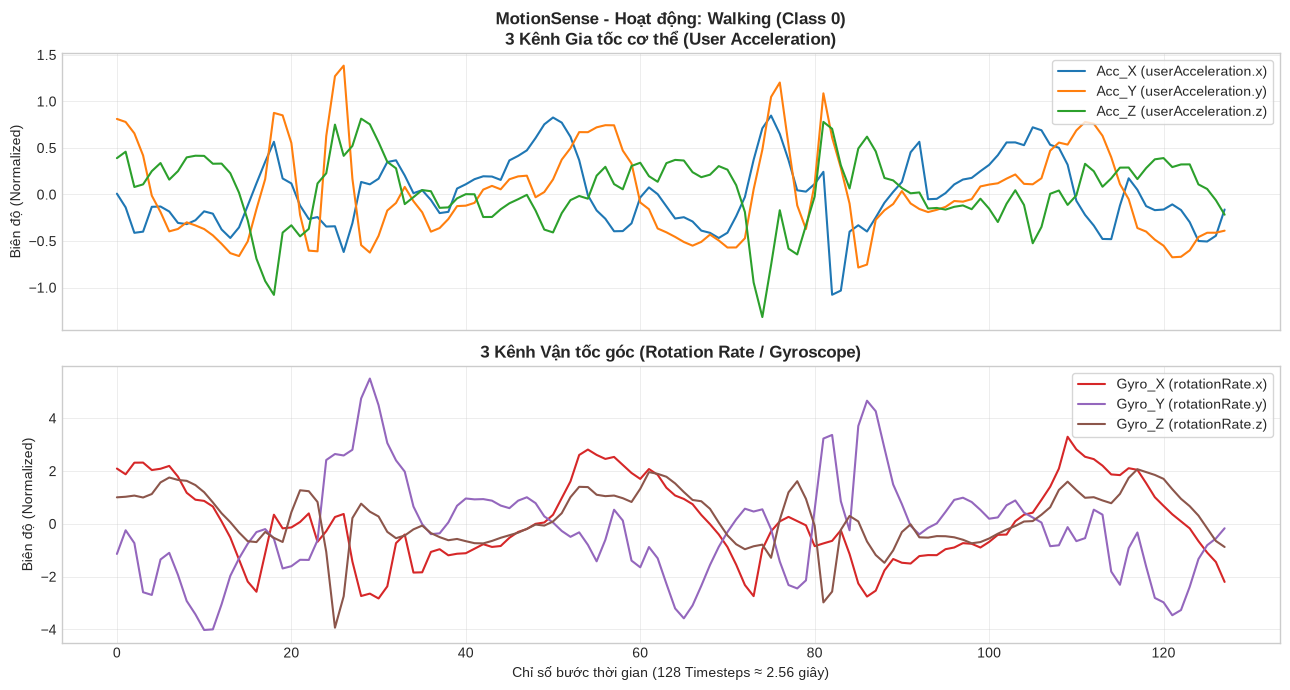

-> Đang vẽ: Upstairs (Mẫu index: 2143)


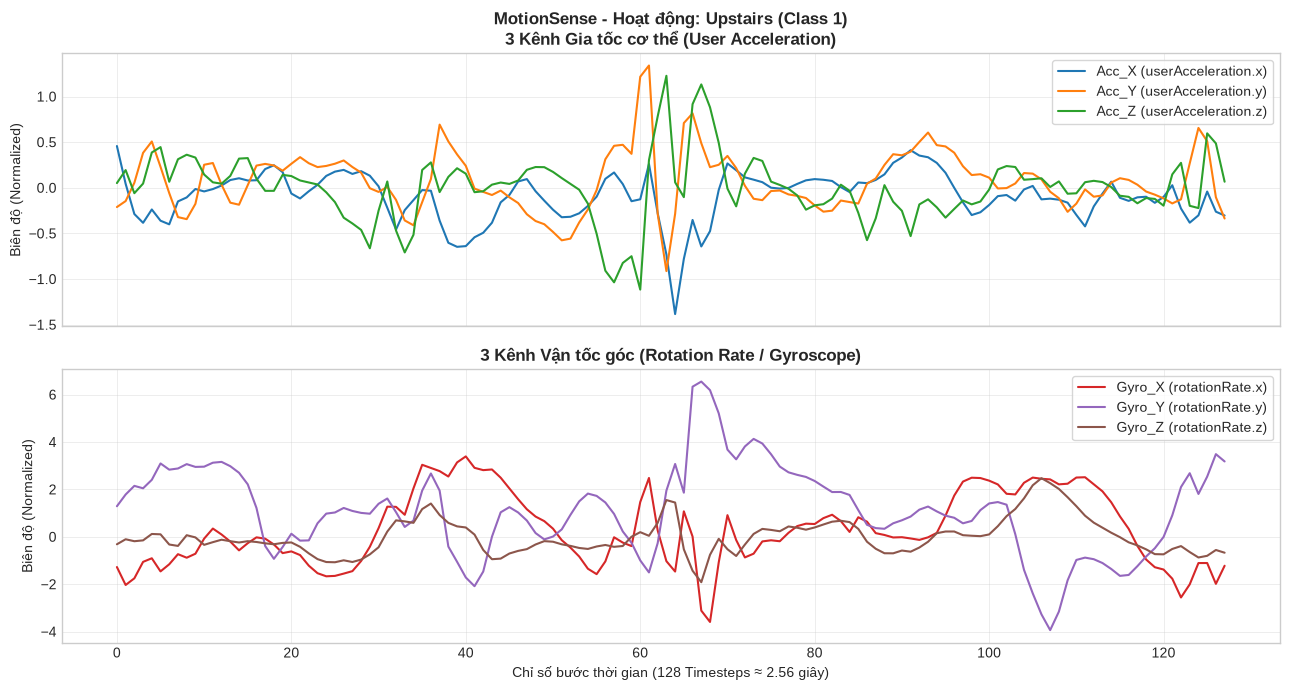

-> Đang vẽ: Downstairs (Mẫu index: 915)


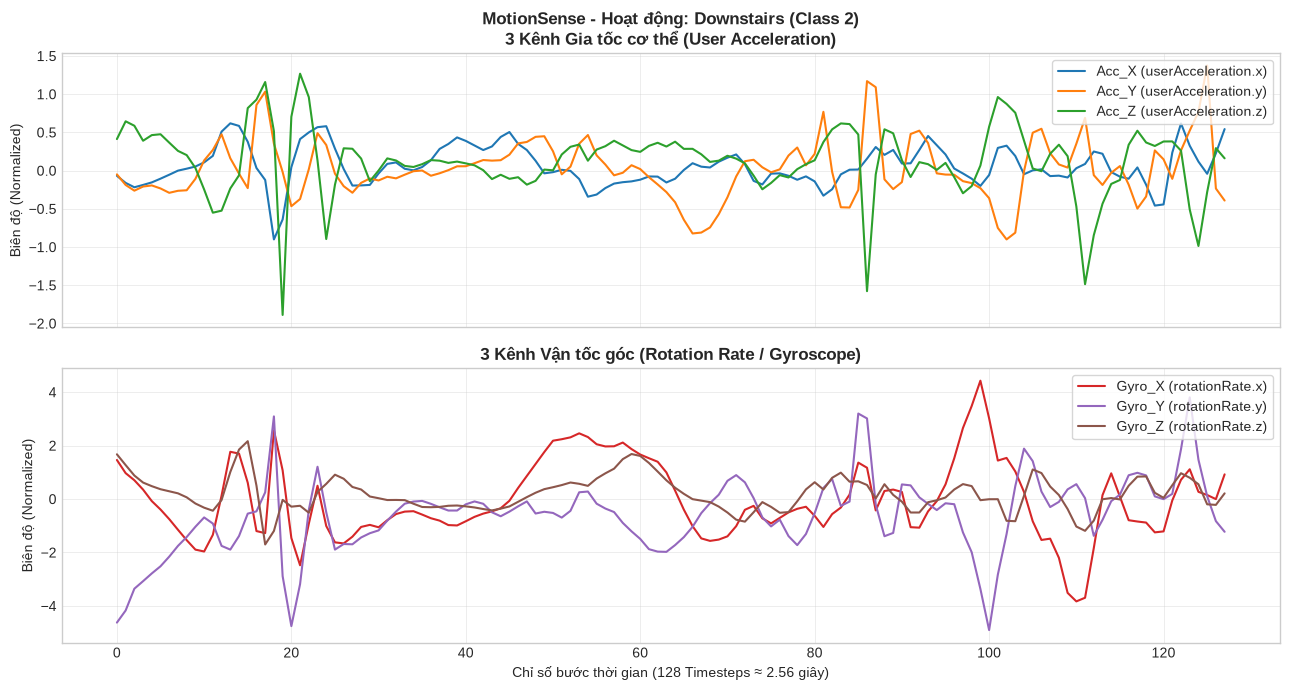

-> Đang vẽ: Sitting (Mẫu index: 4716)


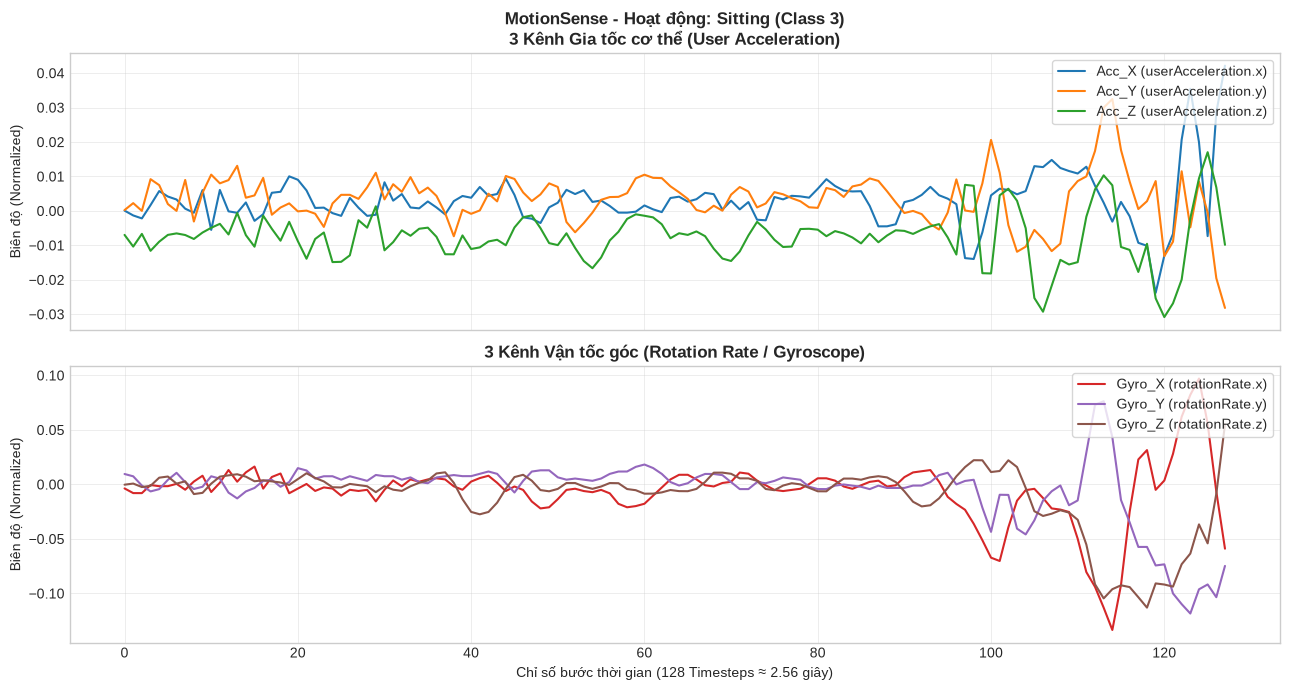

-> Đang vẽ: Standing (Mẫu index: 4060)


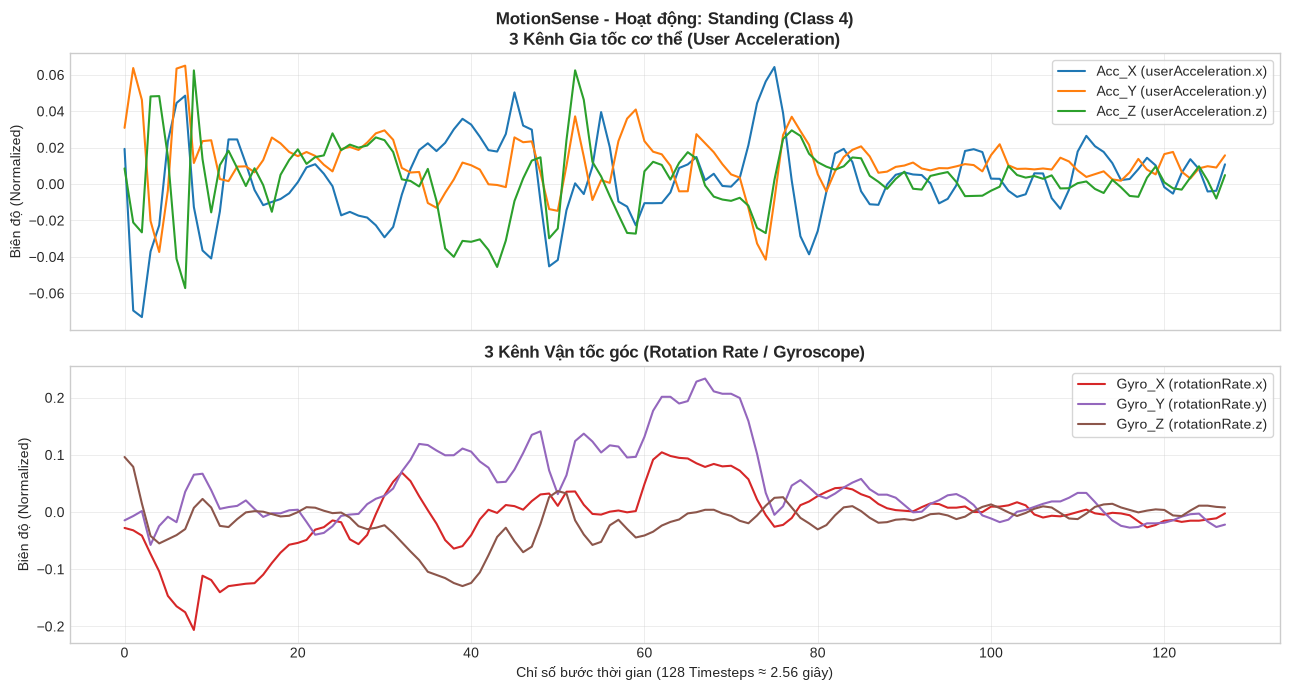

In [1]:
"""
=============================================================================
VAI TRÒ CỦA FILE:
    - Nạp 1 mẫu dữ liệu đã tiền xử lý (processed window: 6 kênh, 128 timesteps)
      từ tập dữ liệu MotionSense.
    - Trực quan hóa sóng tín hiệu 6 kênh:
        + Subplot 1: 3 trục Gia tốc người dùng (User Acceleration X, Y, Z).
        + Subplot 2: 3 trục Vận tốc góc (Rotation Rate X, Y, Z).
=============================================================================
"""

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch
from config.motionsense_config import MotionSenseConfig

# Đường dẫn tới file dữ liệu đã xử lý của MotionSense
DATA_PATH = MotionSenseConfig.DATA_ALL_PATH

# 5 lớp hoạt động chung
CLASS_NAMES = ['Walking', 'Upstairs', 'Downstairs', 'Sitting', 'Standing']
CHANNEL_NAMES_ACC = ['Acc_X (userAcceleration.x)', 'Acc_Y (userAcceleration.y)', 'Acc_Z (userAcceleration.z)']
CHANNEL_NAMES_GYRO = ['Gyro_X (rotationRate.x)', 'Gyro_Y (rotationRate.y)', 'Gyro_Z (rotationRate.z)']


def plot_activity(sample_signal, class_idx, class_name, save_fig=False):
    plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
    fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
    time_steps = np.arange(sample_signal.shape[1])  # 0 -> 127 (128 samples = 2.56s)

    # 1. Vẽ 3 kênh gia tốc
    axes[0].plot(time_steps, sample_signal[0], label=CHANNEL_NAMES_ACC[0], color='tab:blue', linewidth=1.5)
    axes[0].plot(time_steps, sample_signal[1], label=CHANNEL_NAMES_ACC[1], color='tab:orange', linewidth=1.5)
    axes[0].plot(time_steps, sample_signal[2], label=CHANNEL_NAMES_ACC[2], color='tab:green', linewidth=1.5)
    axes[0].set_title(f"MotionSense - Hoạt động: {class_name} (Class {class_idx})\n3 Kênh Gia tốc cơ thể (User Acceleration)", fontsize=12, fontweight='bold')
    axes[0].set_ylabel("Biên độ (Normalized)")
    axes[0].legend(loc="upper right", frameon=True)

    # 2. Vẽ 3 kênh con quay hồi chuyển
    axes[1].plot(time_steps, sample_signal[3], label=CHANNEL_NAMES_GYRO[0], color='tab:red', linewidth=1.5)
    axes[1].plot(time_steps, sample_signal[4], label=CHANNEL_NAMES_GYRO[1], color='tab:purple', linewidth=1.5)
    axes[1].plot(time_steps, sample_signal[5], label=CHANNEL_NAMES_GYRO[2], color='tab:brown', linewidth=1.5)
    axes[1].set_title("3 Kênh Vận tốc góc (Rotation Rate / Gyroscope)", fontsize=12, fontweight='bold')
    axes[1].set_xlabel("Chỉ số bước thời gian (128 Timesteps ≈ 2.56 giây)")
    axes[1].set_ylabel("Biên độ (Normalized)")
    axes[1].legend(loc="upper right", frameon=True)

    plt.tight_layout()

    if save_fig:
        out_dir = PROJECT_ROOT / "visualizations" / "motionsense"
        out_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(out_dir / f"motionsense_class_{class_idx}_{class_name}.png", dpi=300)

    plt.show()


def visualize_all_classes_motionsense(save_fig=False):
    if not DATA_PATH.exists():
        raise FileNotFoundError(f"Không tìm thấy file dữ liệu tại: {DATA_PATH}")

    data = torch.load(DATA_PATH, map_location="cpu")
    X = data["samples"]
    y = data["labels"].squeeze()

    if isinstance(X, torch.Tensor):
        X = X.numpy()
    if isinstance(y, torch.Tensor):
        y = y.numpy()

    # Tìm mẫu đầu tiên xuất hiện của mỗi lớp và vẽ
    for class_idx, class_name in enumerate(CLASS_NAMES):
        indices = np.where(y == class_idx)[0]
        if len(indices) == 0:
            print(f"[Cảnh báo] Không tìm thấy mẫu nào thuộc lớp {class_name} (Class {class_idx})")
            continue
        first_sample_idx = indices[0]
        print(f"-> Đang vẽ: {class_name} (Mẫu index: {first_sample_idx})")

        NUM_WINDOWS = 1
        long_signal = np.concatenate([X[first_sample_idx + i] for i in range(NUM_WINDOWS)], axis=1)
        plot_activity(long_signal, class_idx, class_name, save_fig=save_fig)


if __name__ == "__main__":
    visualize_all_classes_motionsense(save_fig=False)